### Decision Tree

##### How a Decision Tree Works (Step-by-Step)
A Decision Tree splits your dataset into smaller, more homogeneous subsets based on a series of binary (Yes/No) questions.

Root Node: The very top of the tree, which contains the entire training dataset. The algorithm evaluates every single feature to find the best first split.

Recursive Binary Splitting: The algorithm chooses a feature and a threshold value that divides the data into two branches (Left and Right). This process repeats recursively for each new child node.

Pure Nodes: At each split, the tree tries to make the child nodes as "pure" as possible, meaning the rows inside the node belong mostly to one single class (e.g., mostly sick patients or mostly healthy patients).

Terminal (Leaf) Nodes: Nodes where the splitting stops. These nodes assign the final prediction label based on a majority vote of the samples trapped inside that leaf.

##### Advantages
High Interpretability: It operates like a human flowchart ("White-Box" model). You can track the exact logical path behind any prediction.

No Feature Scaling Required: Because it evaluates features individually rather than calculating spatial distances or gradients, you do not need to apply StandardScaler or MinMaxScaler.

Handles Mixed Data Types: It handles a combination of continuous numerical columns and categorical binary/text columns right out of the box.

Captures Non-Linear Relationships: It easily maps complex, curved decision borders without requiring manual feature transformations.

Handles Interaction Effects: It naturally detects how features interact (e.g., Blood Pressure might only be dangerous if Age is above 60).

##### Disadvantages
High Propensity to Overfit: If left unconstrained, a tree will keep growing until it perfectly memorizes the training data, leading to poor real-world testing accuracy.

High Instability (High Variance): A tiny alteration in your training dataset can completely restructure the entire tree layout.

Greedy Algorithm Limitations: It uses a local optimum approach (finding the best split right now at this exact node) rather than planning globally, which doesn't guarantee the absolute best overall tree architecture.

Biased Toward Dominant Features: It can display a structural bias toward features containing a large number of unique numeric thresholds or categorical levels.

##### Best Scenarios to Use:
When you need to explain the exact reasoning behind a decision to non-technical stakeholders, professors, or regulatory bodies.

When your dataset is a messy mix of categorical labels and continuous numbers, and you want a quick baseline model without heavy feature engineering.

When you suspect your data patterns are highly non-linear or hierarchical.

##### Gini Impurity Math
Gini measures the probability of misclassifying a randomly chosen element from the node.

$$Gini = 1 - \sum_{i=0}^{1} P_i^2 = 1 - (P_0^2 + P_1^2)$$

Scale: Ranges from 0.0 (Perfect purity, all rows belong to one class) to 0.5 (Maximum chaos, a perfect 50/50 mix).


Speed: Faster because it relies on simple multiplication and squaring operations.

##### Entropy Math

Entropy originates from Information Theory and measures the exact level of disorder, uncertainty, or chaos in a node.

$$Entropy = - \sum_{i=0}^{1} P_i \log_2(P_i) = - [P_0 \log_2(P_0) + P_1 \log_2(P_1)]$$

Scale: Ranges from 0.0 (Perfect purity, zero chaos) to 1.0 (Maximum uncertainty, a perfect 50/50 mix).

Speed: Slower because calculating logarithmic operations requires more CPU processing cycles.

### Implementing decision tree

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv(r"E:\sculptsoft\22 June\drug200.csv")
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [5]:
df["Drug"].value_counts()

Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

In [6]:
X = df.drop(columns=['Drug'])

In [7]:
X.head()

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,F,HIGH,HIGH,25.355
1,47,M,LOW,HIGH,13.093
2,47,M,LOW,HIGH,10.114
3,28,F,NORMAL,HIGH,7.798
4,61,F,LOW,HIGH,18.043


In [8]:
X_encoded = pd.get_dummies(X, columns=['Sex', 'BP', 'Cholesterol'], drop_first=True)

In [9]:
X_encoded.head()

,Age,Na_to_K,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,23,25.355,False,False,False,False
1,47,13.093,True,True,False,False
2,47,10.114,True,True,False,False
3,28,7.798,False,False,True,False
4,61,18.043,False,True,False,False


In [10]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Drug'])

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.5, random_state=42, stratify=y
)

In [12]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)
predictions = tree_model.predict(X_test)

In [13]:
tree_model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)
predictions_entropy = tree_model.predict(X_test)

In [14]:
from sklearn.metrics import classification_report, accuracy_score
print(classification_report(y_test, predictions, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

       drugA       0.60      1.00      0.75        12
       drugB       0.00      0.00      0.00         8
       drugC       0.40      1.00      0.57         8
       drugX       1.00      0.63      0.77        27
       drugY       1.00      0.96      0.98        45

    accuracy                           0.80       100
   macro avg       0.60      0.72      0.61       100
weighted avg       0.82      0.80      0.78       100



C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
print(classification_report(y_test, predictions_entropy, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

       drugA       0.60      1.00      0.75        12
       drugB       0.00      0.00      0.00         8
       drugC       0.40      1.00      0.57         8
       drugX       1.00      0.63      0.77        27
       drugY       1.00      0.96      0.98        45

    accuracy                           0.80       100
   macro avg       0.60      0.72      0.61       100
weighted avg       0.82      0.80      0.78       100



C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


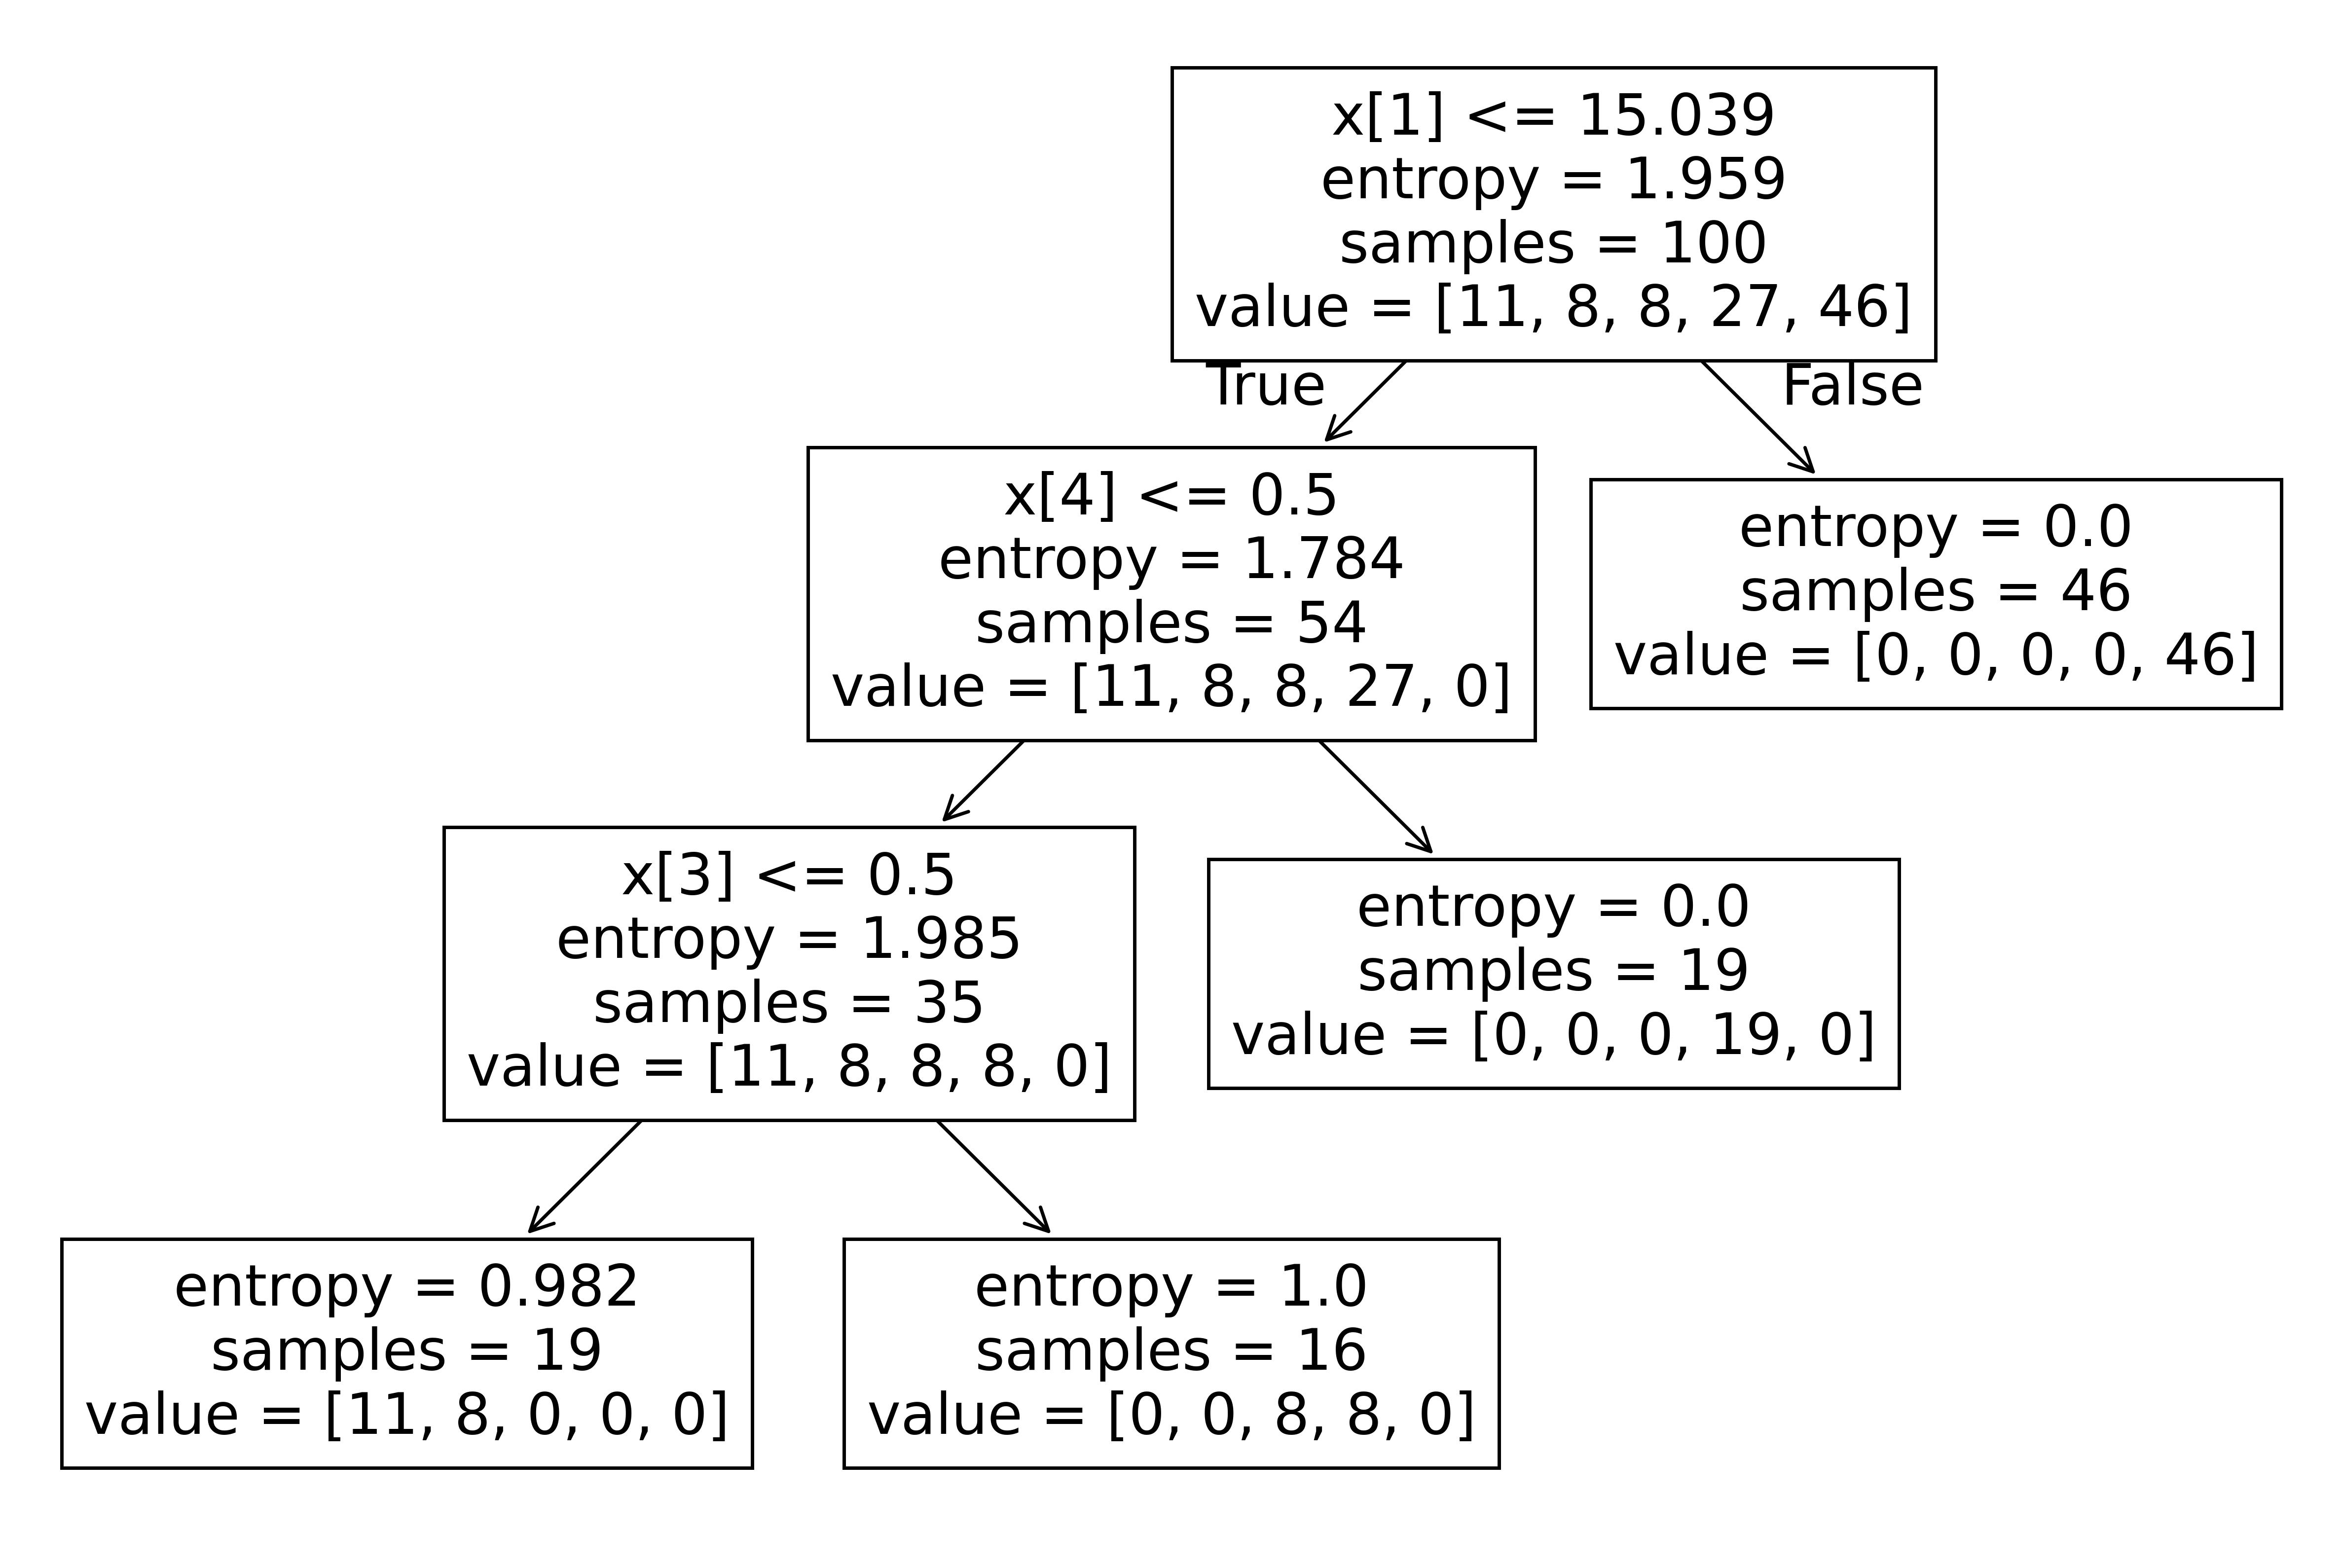

In [16]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8), dpi=500)
plot_tree(tree_model)
plt.show()

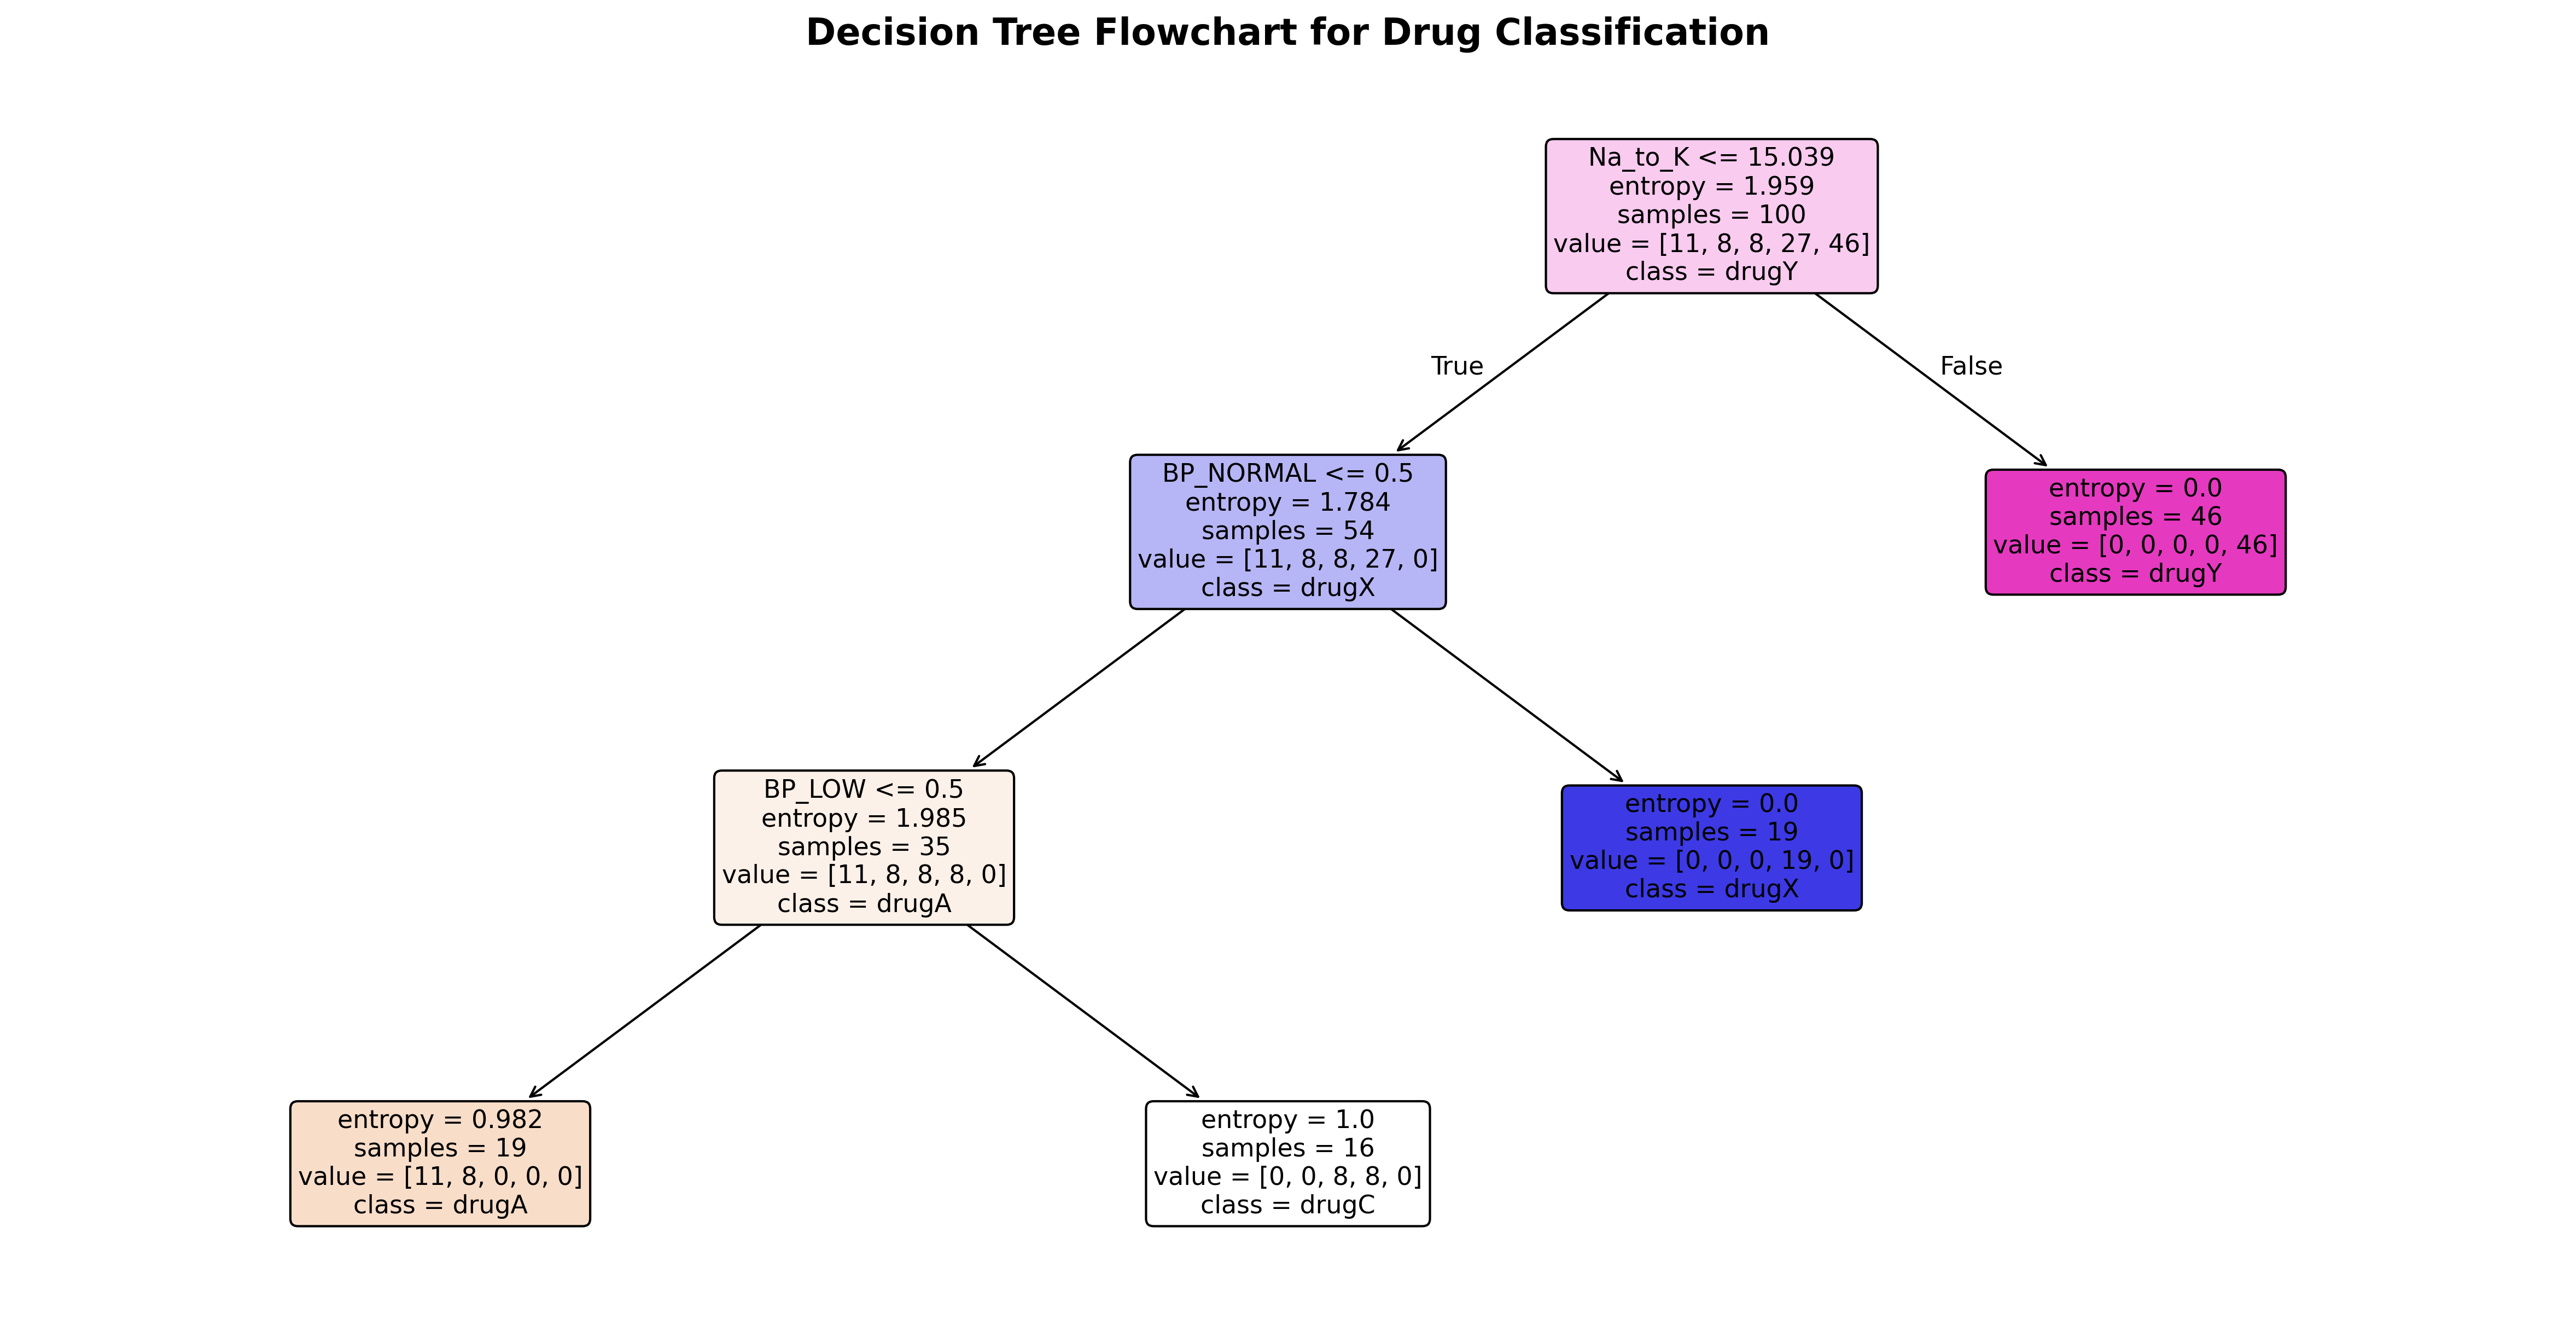

In [17]:
from sklearn.tree import plot_tree

# 1. Set up a large, clear figure size so text doesn't overlap
plt.figure(figsize=(20, 10), dpi=300)

# 2. Plot the tree with custom styling configurations
plot_tree(
    tree_model,
    feature_names=list(X_encoded.columns),        # Shows feature names instead of X[0], X[1]
    class_names=list(label_encoder.classes_),     # Shows 'drugY', 'drugC' instead of 0, 1, 2
    filled=True,                                  # Colors the nodes based on their dominant class
    rounded=True,                                 # Rounds the edges of the node boxes
    fontsize=11                                   # Makes text legible
)

# 3. Add a title and show the plot cleanly
plt.title("Decision Tree Flowchart for Drug Classification", fontsize=16, weight='bold')
plt.show()

#### Post-Prunning and Pre-Prunning

#### Post_prunning : It is mainly used to get rid of the conditions like overfitting in decision tree for which we do not go till the leaf node we some where stop before it in the conditions like (6Y/2N) where the majority is Y so the output for that node will be Y and we will not evaluate it further till the leaf node. IT IS MAINLY USED FOR SMALL DATA

#### Pre-Prunning : Here we provide me the model with the best parameter("Criterrion", "Splitter","max_depth","max_features","CC_aplha") we can use GridSearchCV() and RandomSearchCV to get the best parameter for the model and then apply it. NOTE -> IT WILL NOT PROVIDE THE PARAMETER TILL THE OVERFITTING

In [28]:
parameter = {
    "criterion" : ["gini", "entropy", "log_loss"],
    "splitter" : ["best", "random"],
    "max_depth" : [1,2,3,4],
    "max_features" : ["auto", "sqrt"]
}

In [29]:
from sklearn.model_selection import GridSearchCV

In [36]:
TreeModel = DecisionTreeClassifier(max_depth=4)
cv = GridSearchCV(TreeModel, param_grid=parameter, cv = 3, scoring = "accuracy")

In [37]:
cv.fit(X_train, y_train)

C:\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
72 fits failed out of a total of 144.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
72 fits failed with the following error:
Traceback (most recent call last):
  File "C:\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
    ~~~~~~~~~~~

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(max_depth=4),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4],
                         'max_features': ['auto', 'sqrt'],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [38]:
cv.best_params_

{'criterion': 'log_loss',
 'max_depth': 4,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [39]:
y_pred = cv.predict(X_test)

In [40]:
score = accuracy_score(y_pred, y_test)

In [41]:
score

0.8

In [42]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      0.60      0.75        20
           1       0.00      0.00      0.00         0
           2       0.62      0.38      0.48        13
           3       0.70      0.83      0.76        23
           4       0.98      1.00      0.99        44

    accuracy                           0.80       100
   macro avg       0.66      0.56      0.59       100
weighted avg       0.87      0.80      0.82       100



C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
